## 1) Import Lib


In [22]:
from pathlib import Path
import warnings
import json
import sys
import platform

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")


## 2) Data


In [23]:
PROJECT_ROOT = Path(r"D:/Study/DATN/hand_gesture_windows_control")

DATA_DIR = PROJECT_ROOT.joinpath("data", "processed", "dynamic")
MODEL_DIR = PROJECT_ROOT.joinpath("models", "checkpoints")
REPORT_DIR = PROJECT_ROOT.joinpath("reports", "dynamic")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR.joinpath("train_dynamic_v1.csv")
VAL_CSV = DATA_DIR.joinpath("val_dynamic_v1.csv")
TEST_CSV = DATA_DIR.joinpath("test_dynamic_v1.csv")

SUMMARY_CSV = REPORT_DIR.joinpath("dynamic_model_comparison_summary.csv")

RANDOM_SEED = 42

# META_COLUMNS = {
#     "video_path",
#     "video_name",
#     "subject_id",
#     "session_id",
#     "lighting_condition",
#     "label",
#     "split",
#     "dataset_type",
#     "handedness",
#     "score",
#     "frame_idx",
# }

META_COLUMNS = {
    "video_path",
    "video_name",
    "subject_id",
    "session_id",
    "lighting_condition",
    "label",
    "split",
    "dataset_type",
    "handedness",
    "score",
    "frame_idx",
    "target_frame_count",
    "original_detected_frames",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_CSV   :", TRAIN_CSV)
print("VAL_CSV     :", VAL_CSV)
print("TEST_CSV    :", TEST_CSV)


PROJECT_ROOT: D:\Study\DATN\hand_gesture_windows_control
TRAIN_CSV   : D:\Study\DATN\hand_gesture_windows_control\data\processed\dynamic\train_dynamic_v1.csv
VAL_CSV     : D:\Study\DATN\hand_gesture_windows_control\data\processed\dynamic\val_dynamic_v1.csv
TEST_CSV    : D:\Study\DATN\hand_gesture_windows_control\data\processed\dynamic\test_dynamic_v1.csv


## 2. Load dữ liệu


In [24]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

FEATURE_COLS = [
    c for c in train_df.columns
    if c.startswith("f") and c[1:].isdigit()
]

FEATURE_COLS = sorted(FEATURE_COLS, key=lambda c: int(c[1:]))

print("Feature dim:", len(FEATURE_COLS))
if len(FEATURE_COLS) == 0:
    raise RuntimeError("Không tìm thấy feature columns số để train.")

labels = sorted(train_df["label"].astype(str).unique().tolist())

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].astype(str).values

X_val = val_df[FEATURE_COLS].values
y_val = val_df["label"].astype(str).values

X_test = test_df[FEATURE_COLS].values
y_test = test_df["label"].astype(str).values

print("Feature dim:", len(FEATURE_COLS))
print("Labels     :", labels)
print("Train shape:", X_train.shape)
print("Val shape  :", X_val.shape)
print("Test shape :", X_test.shape)


Feature dim: 4416
Feature dim: 4416
Labels     : ['move_down', 'move_left', 'move_right', 'move_up', 'no_motion']
Train shape: (60, 4416)
Val shape  : (20, 4416)
Test shape : (20, 4416)


In [25]:
X_train[:1]


array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 4416))

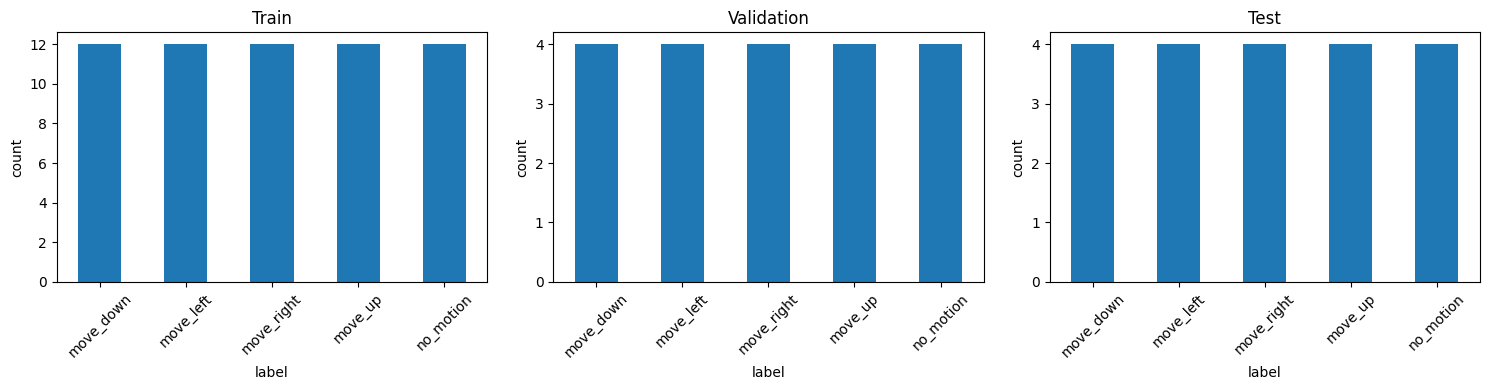

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Train")
val_df["label"].value_counts().plot(kind="bar", ax=axes[1], title="Validation")
test_df["label"].value_counts().plot(kind="bar", ax=axes[2], title="Test")

for ax in axes:
    ax.set_xlabel("label")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [27]:
display(train_df["label"].value_counts().rename("train_count").to_frame())
display(val_df["label"].value_counts().rename("val_count").to_frame())
display(test_df["label"].value_counts().rename("test_count").to_frame())


,train_count
label,
move_down,12
move_left,12
move_right,12
move_up,12
no_motion,12


,val_count
label,
move_down,4
move_left,4
move_right,4
move_up,4
no_motion,4


,test_count
label,
move_down,4
move_left,4
move_right,4
move_up,4
no_motion,4


## 3. Train Model (SVM, logistic reg, random forest, svm linear)


In [28]:
models = {
    "svm_rbf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_SEED
        ))
    ]),
    "logistic_regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ]),
    "svm_linear": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ]),
}

list(models.keys())


['svm_rbf', 'logistic_regression', 'random_forest', 'svm_linear']

In [29]:
# hàm đánh giá model

def evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    val_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    val_report = classification_report(
        y_val, y_val_pred, labels=labels, digits=4, zero_division=0
    )
    test_report = classification_report(
        y_test, y_test_pred, labels=labels, digits=4, zero_division=0
    )

    val_cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=labels)

    return {
        "model_name": model_name,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "test_weighted_f1": test_weighted_f1,
        "val_report": val_report,
        "test_report": test_report,
        "val_cm": val_cm,
        "test_cm": test_cm,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }


In [30]:
results = {}
summary_rows = []

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        labels=labels,
    )

    results[model_name] = {
        "model": model,
        **result
    }

    summary_rows.append({
        "model": model_name,
        "val_accuracy": round(result["val_acc"], 6),
        "test_accuracy": round(result["test_acc"], 6),
        "val_macro_f1": round(result["val_macro_f1"], 6),
        "test_macro_f1": round(result["test_macro_f1"], 6),
        "val_weighted_f1": round(result["val_weighted_f1"], 6),
        "test_weighted_f1": round(result["test_weighted_f1"], 6),
    })

    print("Validation Accuracy :", round(result["val_acc"], 4))
    print("Test Accuracy       :", round(result["test_acc"], 4))
    print("Validation Macro F1 :", round(result["val_macro_f1"], 4))
    print("Test Macro F1       :", round(result["test_macro_f1"], 4))


Training: svm_rbf
Validation Accuracy : 1.0
Test Accuracy       : 1.0
Validation Macro F1 : 1.0
Test Macro F1       : 1.0
Training: logistic_regression
Validation Accuracy : 1.0
Test Accuracy       : 1.0
Validation Macro F1 : 1.0
Test Macro F1       : 1.0
Training: random_forest
Validation Accuracy : 1.0
Test Accuracy       : 1.0
Validation Macro F1 : 1.0
Test Macro F1       : 1.0
Training: svm_linear
Validation Accuracy : 1.0
Test Accuracy       : 1.0
Validation Macro F1 : 1.0
Test Macro F1       : 1.0


## 4. Kết quả train


In [31]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["test_macro_f1", "val_macro_f1", "test_accuracy", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

summary_df


,model,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,val_weighted_f1,test_weighted_f1
0,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0
1,logistic_regression,1.0,1.0,1.0,1.0,1.0,1.0
2,random_forest,1.0,1.0,1.0,1.0,1.0,1.0
3,svm_linear,1.0,1.0,1.0,1.0,1.0,1.0


In [32]:
best_row = summary_df.iloc[0]
BEST_MODEL_NAME = best_row["model"]

print("=== BEST MODEL ===")
print(best_row)
print("\nChosen model:", BEST_MODEL_NAME)


=== BEST MODEL ===
model               svm_rbf
val_accuracy            1.0
test_accuracy           1.0
val_macro_f1            1.0
test_macro_f1           1.0
val_weighted_f1         1.0
test_weighted_f1        1.0
Name: 0, dtype: object

Chosen model: svm_rbf


In [33]:
summary_csv_path = REPORT_DIR.joinpath("dynamic_model_comparison_summary.csv")
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")
print("Model comparison summary saved to:", summary_csv_path)


Model comparison summary saved to: D:\Study\DATN\hand_gesture_windows_control\reports\dynamic\dynamic_model_comparison_summary.csv


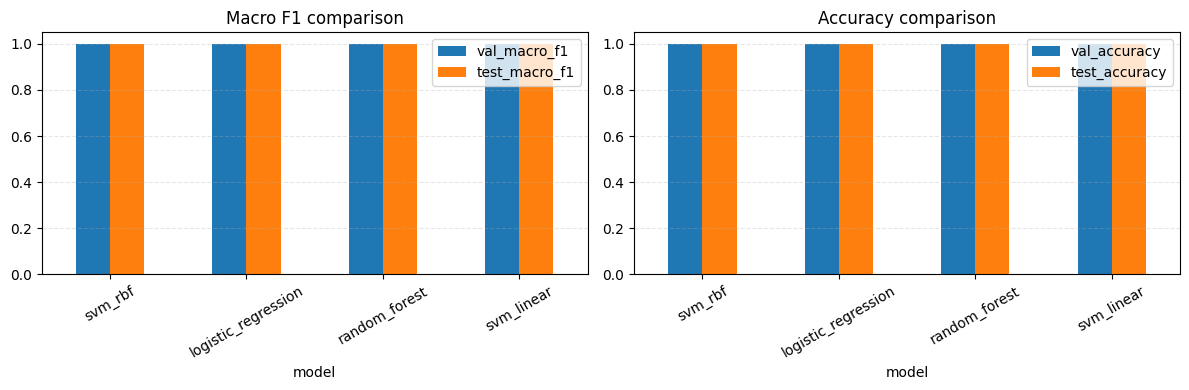

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary_df.plot(
    x="model",
    y=["val_macro_f1", "test_macro_f1"],
    kind="bar",
    ax=axes[0],
    title="Macro F1 comparison"
)

summary_df.plot(
    x="model",
    y=["val_accuracy", "test_accuracy"],
    kind="bar",
    ax=axes[1],
    title="Accuracy comparison"
)

for ax in axes:
    ax.set_xlabel("model")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Classification report từng model


### 5.1) SVM RBF


In [35]:
def show_classification_report(model_name):
    print("[VALIDATION REPORT]")
    print(results[model_name]["val_report"])

    print("[TEST REPORT]")
    print(results[model_name]["test_report"])

def show_confusion_matrix(model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["val_cm"],
        display_labels=labels
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{model_name} - Validation")

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["test_cm"],
        display_labels=labels
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()


[VALIDATION REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20

[TEST REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000

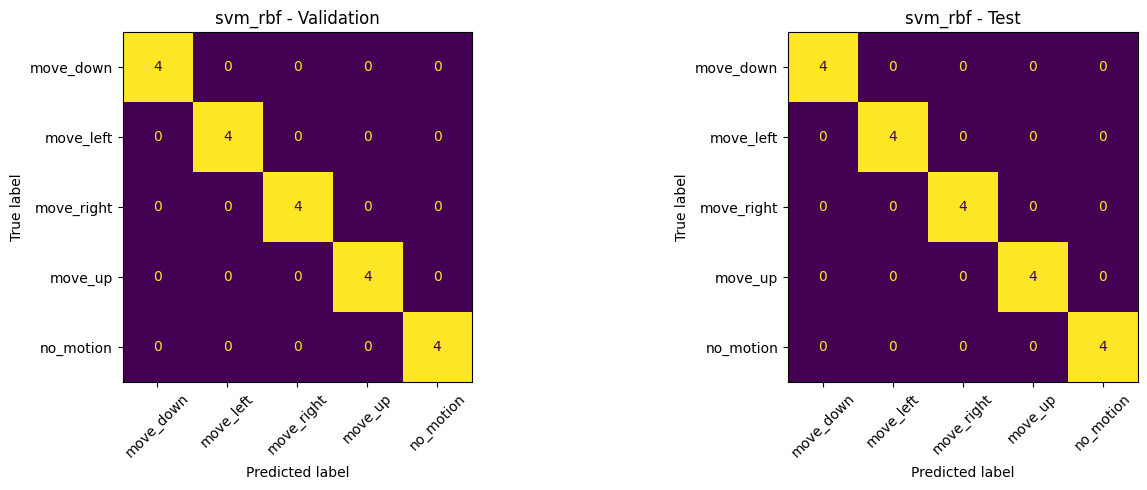

In [36]:
show_classification_report("svm_rbf")
show_confusion_matrix("svm_rbf")


### 5.2) Model logistic_regression


[VALIDATION REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20

[TEST REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000

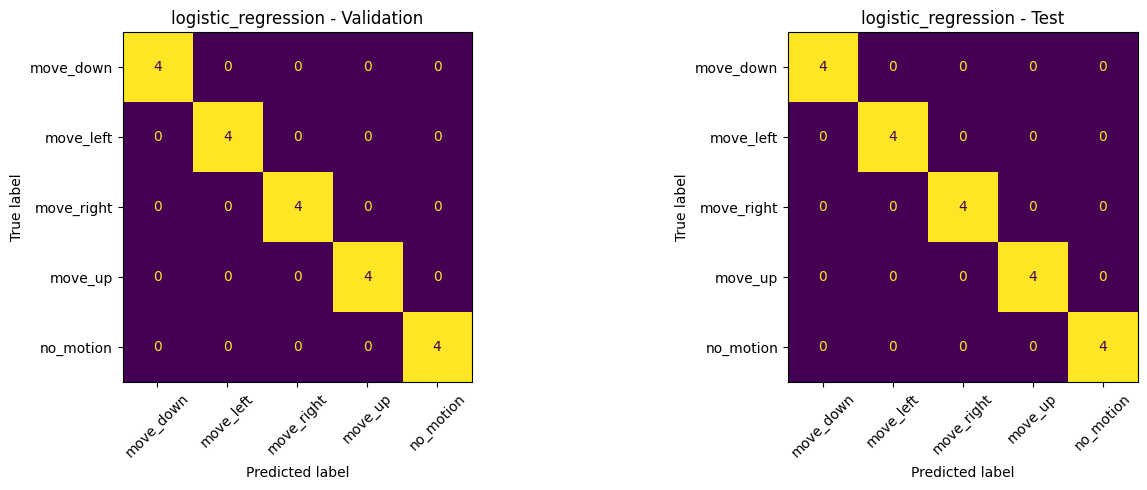

In [37]:
show_classification_report("logistic_regression")
show_confusion_matrix("logistic_regression")


### 5.3) Model random_forest


[VALIDATION REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20

[TEST REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000

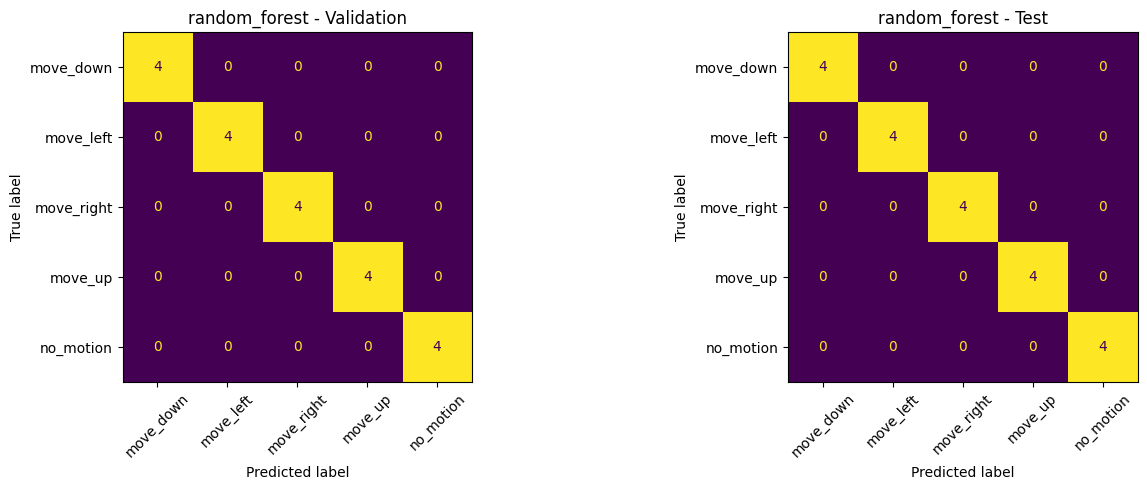

In [38]:
show_classification_report("random_forest")
show_confusion_matrix("random_forest")


### 5.4) Model svm_linear


[VALIDATION REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000        20

[TEST REPORT]
              precision    recall  f1-score   support

   move_down     1.0000    1.0000    1.0000         4
   move_left     1.0000    1.0000    1.0000         4
  move_right     1.0000    1.0000    1.0000         4
     move_up     1.0000    1.0000    1.0000         4
   no_motion     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        20
   macro avg     1.0000    1.0000    1.0000        20
weighted avg     1.0000    1.0000    1.0000

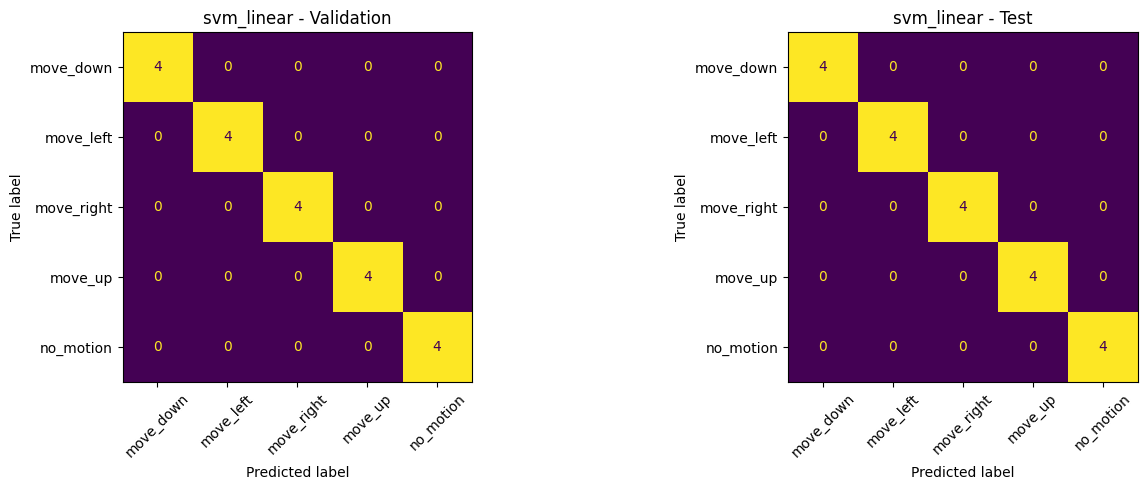

In [39]:
show_classification_report("svm_linear")
show_confusion_matrix("svm_linear")


## 6. Lưu model và báo cáo


In [40]:
print(labels)


['move_down', 'move_left', 'move_right', 'move_up', 'no_motion']


In [41]:
BEST_MODEL_NAME = summary_df.iloc[0]["model"]

BEST_MODEL_PATH = MODEL_DIR / "dynamic_best_model.joblib"
BEST_META_PATH = MODEL_DIR / "dynamic_best_model_meta.json"

best_model = results[BEST_MODEL_NAME]["model"]

joblib.dump(best_model, BEST_MODEL_PATH)

meta = {
    "best_model": BEST_MODEL_NAME,
    "labels": labels,
    "feature_columns": FEATURE_COLS,
    "feature_dim": len(FEATURE_COLS),
    "val_accuracy": float(results[BEST_MODEL_NAME]["val_acc"]),
    "test_accuracy": float(results[BEST_MODEL_NAME]["test_acc"]),
    "val_macro_f1": float(results[BEST_MODEL_NAME]["val_macro_f1"]),
    "test_macro_f1": float(results[BEST_MODEL_NAME]["test_macro_f1"]),
    "data_files": {
        "train_csv": str(TRAIN_CSV),
        "val_csv": str(VAL_CSV),
        "test_csv": str(TEST_CSV),
    },
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "note": "Best model chosen by highest test_macro_f1, then val_macro_f1, then accuracy."
}

BEST_META_PATH.write_text(
    json.dumps(meta, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved model to:", BEST_MODEL_PATH)
print("Saved metadata to:", BEST_META_PATH)
print("Best model name:", BEST_MODEL_NAME)


Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\dynamic_best_model.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\dynamic_best_model_meta.json
Best model name: svm_rbf


In [42]:
report_md_path = REPORT_DIR / "dynamic_model_report_v2.md"

lines = []
lines.append("# Dynamic model training report\n\n")
lines.append("## Data\n")
lines.append(f"- Train: `{TRAIN_CSV}`\n")
lines.append(f"- Val: `{VAL_CSV}`\n")
lines.append(f"- Test: `{TEST_CSV}`\n")
lines.append(f"- Feature dim: `{len(FEATURE_COLS)}`\n\n")

lines.append("## Model comparison\n\n")
lines.append(summary_df.to_markdown(index=False))
lines.append("\n\n")

lines.append("## Best model\n")
lines.append(f"- Model: `{BEST_MODEL_NAME}`\n")
lines.append(f"- Validation macro F1: `{results[BEST_MODEL_NAME]['val_macro_f1']:.4f}`\n")
lines.append(f"- Test macro F1: `{results[BEST_MODEL_NAME]['test_macro_f1']:.4f}`\n")

report_md_path.write_text("".join(lines), encoding="utf-8")
print("Saved markdown report to:", report_md_path)


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.